In [16]:
import pandas as pd 

import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("All libraries imported sucessfully") 

All libraries imported sucessfully


In [17]:
# Step -> 2 Data Load 

df = pd.read_csv("patients_data.csv")

In [18]:
df.head()

,patient_id,fever,cough,chest_pain,breathlessness,temperature,diagnosis
0,1,1,1,1,1,40.8,Pneumonia
1,2,1,0,0,0,37.5,Flu
2,3,0,1,0,1,37.2,Asthma
3,4,0,0,0,1,37.2,Asthma
4,5,1,1,0,1,38.9,Pneumonia


In [19]:
df.isnull().sum()

patient_id         0
fever              0
cough              0
chest_pain         0
breathlessness     0
temperature       12
diagnosis          0
dtype: int64

In [20]:
df = df.drop(columns="patient_id", errors = "ignore")

df = df.drop_duplicates().reset_index(drop=True)

df["temperature"] = df["temperature"].fillna(df["temperature"].median())

In [21]:
df.duplicated().sum()

np.int64(4)

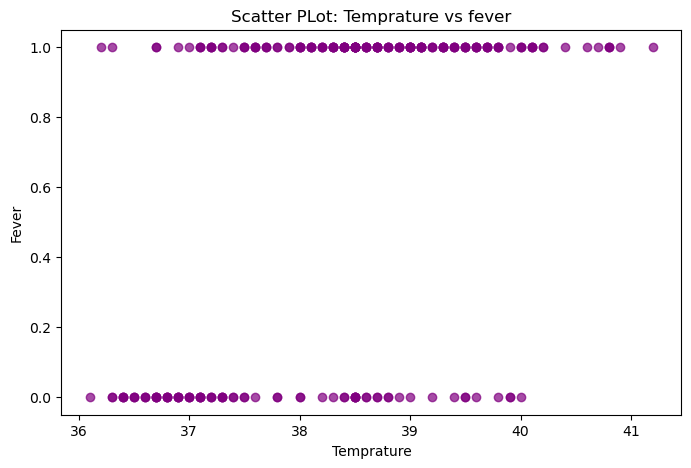

In [22]:
# Scatter Plot Visulization 

plt.figure(figsize=(8, 5))

plt.scatter(df["temperature"],
df["fever"], color="purple",alpha=0.7)           

plt.xlabel("Temprature")
plt.ylabel("Fever")

plt.title("Scatter PLot: Temprature vs fever")

plt.show()

In [23]:
# Features x aur target y alag karna 
X = df[["fever","cough","chest_pain","breathlessness","temperature"]]

le = LabelEncoder()

y = le.fit_transform(df["diagnosis"])

le.classes_


array(['Asthma', 'Flu', 'Pneumonia'], dtype=object)

In [24]:
# step - 4 
# Train Test Split aur scaling 

X_train, X_test, y_train , y_test = train_test_split(
    X, y , test_size=0.2,
    random_state=42, stratify=y
)

X_train.shape, X_test.shape 
    

((191, 5), (48, 5))

In [26]:
# Logistic Regression ke liye  Data Scale Karna 

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

In [30]:
# Model train Karna -> Decision tree model 

dt = DecisionTreeClassifier(max_depth=4,
random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Trained ! ")
                         

Decision Tree Trained ! 


In [35]:
# model tarin -> Logistic Regression

lr = LogisticRegression(max_iter=1000,
random_state=42)

lr.fit(X_train_s, y_train)

print("Logistic Regression :")


Logistic Regression :


In [36]:
# Step -> 6 Model evalute Karna 
# confussion matrix -> (Decsion tree Acuuracy)
pred_dt = dt.predict(X_test)
accuracy_score(y_test, pred_dt)

0.7708333333333334

In [37]:
# confusion matrix -> ( Logistic Regression Acuracy )
pred_lr = lr.predict(X_test_s)

accuracy_score(y_test, pred_lr)

0.75

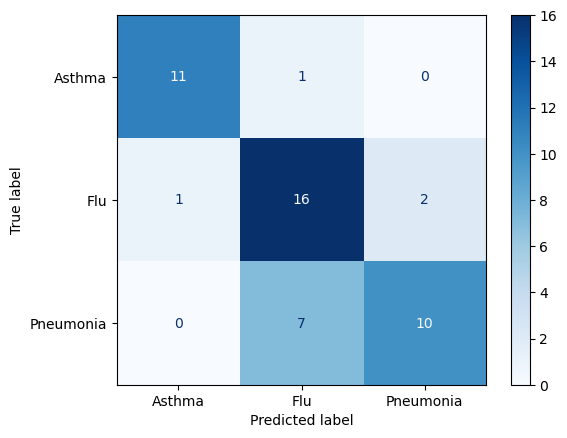

In [38]:
# Decision Tree Confusion Matrix garph 
cm_dt = confusion_matrix(y_test, pred_dt)

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,display_labels=le.classes_)

disp_dt.plot(cmap="Blues")

plt.show()

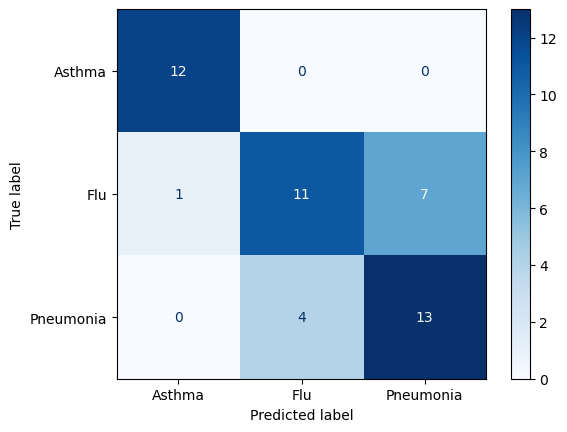

In [39]:
# Logistic Regression Confusion Matrix Graph 

cm_lr = confusion_matrix(y_test, pred_lr)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,display_labels=le.classes_)

disp_lr.plot(cmap="Blues")
plt.show()

In [40]:
# Model tuning (GridSearchCV)
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [2, 3, 4, 5, None], "min_samples_leaf": [1, 3, 5]},
    cv=5,
    scoring="accuracy"
)


grid.fit(X_train, y_train)


print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 3}


In [41]:
# Prediction new patients 
new_patient = pd.DataFrame([[1, 1, 1, 1, 39.5]], columns=X.columns)


le.inverse_transform(dt.predict(new_patient))

array(['Pneumonia'], dtype=object)

In [42]:
# (Logistic Regression Probability Check)
pd.Series(
    lr.predict_proba(scaler.transform(new_patient))[0],
    index=le.classes_
).round(3)

Asthma       0.000
Flu          0.045
Pneumonia    0.954
dtype: float64

In [43]:
import joblib

joblib.dump(lr, "logistic_model.pkl")
joblib.dump(dt, "dt_model.pkl")  # Yeh raha Decision Tree!
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Dono models successfully save ho gaye hain!")

Dono models successfully save ho gaye hain!
